<a href="https://colab.research.google.com/github/viviantram03/labb-1/blob/main/vizandstorytelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Overview and Data Loading
In this section, I load the dataset and the necessary libraries for analysis. The goal is to prepare the raw data for a deep dive into booking patterns and cancellation risks.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# ignore warning messages for a cleaner output
warnings.filterwarnings("ignore")

# load the dataset
df = pd.read_csv('hotel_bookings.csv')


##2. Feature Explanation

Before cleaning, it can be essential to understand the features (columns). Key variables include:



*   is_canceled: Our target variable (1 = canceled, 0 = not canceled).
*   lead_time: Days between booking and arrival.
*   adr = Average Daily Rate, representing the price per room per day.
*   market_segment: How the booking was made.
*   arrival_date_month: Useful for identifying seasonal trends







##3. Handling Missing Values

During the initial inspection, missing values were identified in four columns. My strategy for handling them is as follows:


*   Children: Missing values were replaced with 0, assuming that the absence of data indicates no children were part of the booking
*   Country: Missing entries were labeled as "Unknown" to maintain the integrity of the geographic analysis without mkaing assumptions about the origin.
*   Agent & Company: Missing IDs were replaced with 0, signifying that the booking was made independently without the involvement of a third-party agency or corporate entity.





In [3]:
# fill missing 'children' with 0, 'country' with 'Unknown', and 'agent'/'company' with 0
df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna('Unknown')
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)

##4. Data Conversion

To make the data more usable for plotting and calculation:
*   I converted children and agent IDs to integers.
*   The arrival_date_month was converted to an Ordered Categorical type. This is crucial because standard alphabetical sorting would put "April" before "January".




In [4]:
# convert float columns to integers for cleaner data processing
df['children'] = df['children'].astype(int)
df['agent'] = df['agent'].astype(int)

# convert 'arrival_data_month' to an ordered categorical data type for correct plotting order
ordered_months = ["January", "February", "March", "April", "May", "June",
                  "July", "August", "September", "October", "November", "December"]
df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=ordered_months, ordered=True)

##5. Data Aggregation

I created two new calculated columns:
1. total_stay: Sum of weekend and weeknight stays to see the full duration.
2. total_guests: Sum of adults, children, and babies to see the actual group size.

In [5]:
# calculate total duration of stay and total number of guests booking
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['total_guests'] = df['adults'] + df['children'] + df['babies']

##6. Feasibility Analysis
To ensure the dataset reflects realistic scenarios, I conducted a feasibility check on the guest counts. Any booking where the total_guests sum (adults + children + babies) resulted in 0 was removed, as a valid hotel reservation requires at least one occupant.

In [6]:
original_shape = df.shape[0]

# filter out unfeasible bookings with 0 guests
df = df[df['total_guests'] > 0]

##8. Outlier Removal
The adr (Average Daily Rate) column contained extreme values that could heavily skew statistical averages and mislead the final narrative. I restricted the analysis to a realistic price range where 0≤adr<5000. This removes both negative values and extreme high-end anomalities, ensuring the visualizations represent the typical customer experience accurately.

In [7]:
# filter out extreme outliers: keep only bookings with a valid average daily rate (ADR) between 0 and 5000
df = df[(df['adr'] >= 0) & (df['adr'] < 5000)]

new_shape = df.shape[0]
removed_rows = original_shape - new_shape

# print a summary of the removed outliers
print("--- Data Cleaning ---")
print(f"Original rows: {original_shape}")
print(f"Rows remaining: {new_shape}")
print(f"Removed rows: {removed_rows} ({(removed_rows/original_shape)*100:.2f}%)\n")

--- Data Cleaning ---
Original rows: 119390
Rows remaining: 119208
Removed rows: 182 (0.15%)



##7. Data Visualization (EDA)
In this step, I use a multi-plot figure to examine the key variables from different business perspectives. The visualizations are designed to move from broad seasonal trends to specific guest behaviors and risk factors.

1. Seasonality vs Pricing (ADR per Month):
Using a line plot, I track the Average Daily Rate (ADR) acroess the year. By filtering for non-canceled bookings, we see the actual revenue trends. This helpds identify "high seasons" (where prices peak) and "low seasons", providing a basis for dynamic pricing strategies.

2. Optimal Stay Duration (ADR vs Length of Stay):
I examine how the total length of stay (limited to 1-14 days for clarity) impacts the price. This line plot helps us understand if the hotel offers implicit discounts for longer stays or if prices remain linear, which is vital for revenue management.

3. Predicting Engagement (Special Requests by Segment):
This bar chart analysez which Market Segments are most likely to make special requests. Identifying "high-touch" segments allows the hotel to allocate staff resources more effectively to meet guest expectations.

4. Cancellation Risk Assessment (Lead Time vs. Cancellation):
Using a boxplot (with outliers hidden for a clearer view), I compare the Lead Time for canceled vs. non-canceled bookings. This visualizes whether bookings made far in advance are more volatile, prociding a visual precursor to the statistical t-test.

5. Hotel Type Performance (Cancellation Rate by Hotel):
Finally, I calculate the precentage of cancellations per hotel type. This bar chart provides a clear performance metric, showing which hotel type (City vs. Resort) faces a higher risk of revenue loss due to cancellations.

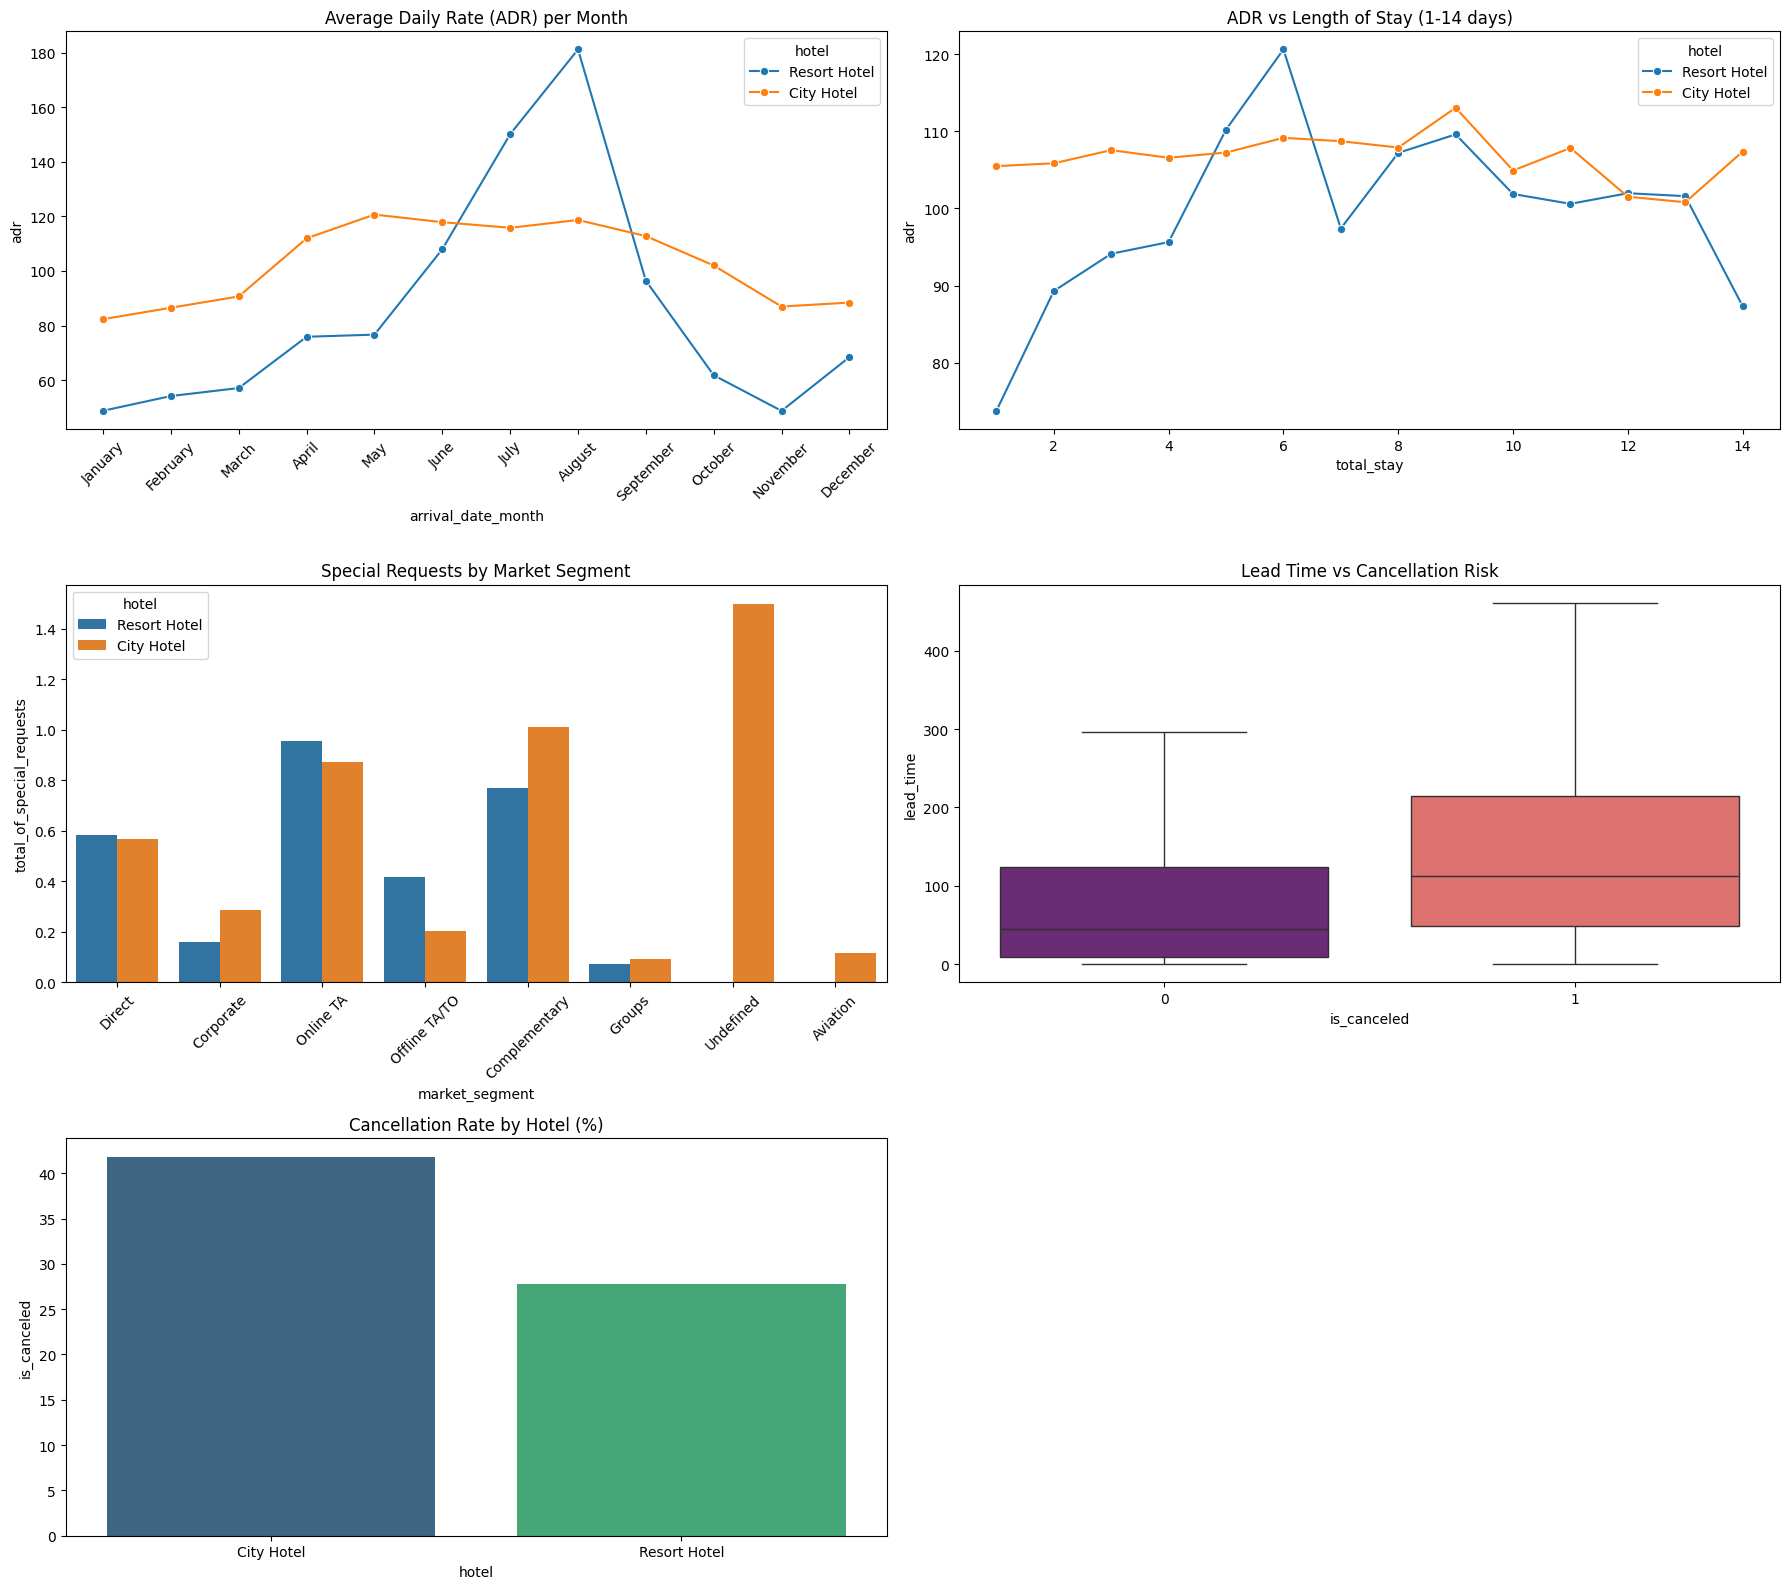

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(18, 16))

# best time of year to book (plotting average daily rate per month)
sns.lineplot(data=df[df['is_canceled'] == 0], x='arrival_date_month', y='adr', hue='hotel', marker='o', errorbar=None, ax=axes[0, 0])
axes[0, 0].set_title('Average Daily Rate (ADR) per Month')
axes[0, 0].tick_params(axis='x', rotation=45)

# optimal length of stay (plotting ADR vs length of stay, filtered up to 14 days for clarity)
stay_data = df[(df['total_stay'] > 0) & (df['total_stay'] <= 14) & (df['is_canceled'] == 0)]
sns.lineplot(data=stay_data, x='total_stay', y='adr', hue='hotel', marker='o', errorbar=None, ax=axes[0, 1])
axes[0, 1].set_title('ADR vs Length of Stay (1-14 days)')

# predicting special requests (plotting total special requests by market segment)
sns.barplot(data=df, x='market_segment', y='total_of_special_requests', hue='hotel', errorbar=None, ax=axes[1, 0])
axes[1, 0].set_title('Special Requests by Market Segment')
axes[1, 0].tick_params(axis='x', rotation=45)

# lead time vs cancellation risk
sns.boxplot(x='is_canceled', y='lead_time', data=df, showfliers=False, ax=axes[1, 1], palette='magma')
axes[1, 1].set_title('Lead Time vs Cancellation Risk')

# cancellation rate by hotel type
cancel_rate = df.groupby('hotel')['is_canceled'].mean().reset_index()
cancel_rate['is_canceled'] = cancel_rate['is_canceled'] * 100
sns.barplot(data=cancel_rate, x='hotel', y='is_canceled', palette='viridis', ax=axes[2, 0])
axes[2, 0].set_title('Cancellation Rate by Hotel (%)')

# remove the empty subplot to make the figure look cleaner
fig.delaxes(axes[2, 1])
plt.tight_layout()
plt.show()

##9. Statstical Significance (T-test)

To move beyond visual observation, I conducted a Welch's T-testto evaluate the relationship between Lead Time and Cancellation Status.
Hypothesis:

*   Null Hypothesis: There is no significant difference in the mean lead time between canceled and non-canceled bookings.
*   Alternative Hypothesis: Canceled bookings have a significantly higher mean lead time than non-canceled bookings.

This test determines if the observed "cancellation risk" for long-term bookings is a real pattern or just random noise.

In [9]:
# isolate 'lead_time' for canceled vs. not-canceled bookings to test for statistical difference
canceled_lead = df[df['is_canceled'] == 1]['lead_time']
not_canceled_lead = df[df['is_canceled'] == 0]['lead_time']

# perform Welch's t-test
t_stat, p_value = stats.ttest_ind(canceled_lead, not_canceled_lead, equal_var=False)

# print the test statistics
print("--- T-test Results ---")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}\n")

--- T-test Results ---
T-statistic: 98.9415
P-value: 0.0000e+00



##10. Save Refined Data

In [10]:
df.to_excel('cleaned_hotel_bookings.xlsx', index=False)
df.to_pickle('cleaned_hotel_bookings.pkl')
print("Data saved to Excel and Pickle formats.")

Data saved to Excel and Pickle formats.
